# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [96]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [97]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [98]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [99]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [100]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [101]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [102]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [103]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [104]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [105]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [106]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
    - Las columnas city, churn_date, date, duration y length presentan valores faltantes, siendo más notable la ausencia de datos en churn_date, duration y length
- Indica qué harías: ¿imputar, eliminar, ignorar?
    - Los valores faltantes se mantendrán temporalmente para investigar su origen y determinar si representan un problema de calidad o un comportamiento esperado de los datos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [107]:
# explorar columnas numéricas de users
users[['age', 'user_id']].describe()

,age,user_id
count,4000.000000,4000.000000
mean,33.739750,11999.500000
std,123.232257,1154.844867
min,-999.000000,10000.000000
25%,32.000000,10999.750000
50%,47.000000,11999.500000
75%,63.000000,12999.250000
max,79.000000,13999.000000


- La columna 'user_id' presenta valores consistentes con un identificador único de clientes y no muestra indicios de valores atípicos o inconsistencias.
- La columna 'age' presenta un valor mínimo de -999, el cual no es válido para representar una edad y sugiere la presencia de un posible valor sentinel que podría estar afectando las medidas estadísticas de la variable.

In [108]:
# explorar columnas numéricas de usage
usage[['id','user_id','duration','length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` presentan valores consistentes con identificadores de registros y usuarios, sin evidencias de inconsistencias aparentes.
- Las columnas `duration` y `length` presentan algunos valores extremos que requieren revisión adicional para determinar si corresponden a comportamientos válidos o registros atípicos.

In [109]:
# explorar columnas categóricas de users
columnas_user = users[['city', 'plan']].describe()
print (columnas_user)

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` contiene siete ciudades distintas y presenta valores faltantes; Bogotá es la ciudad más frecuente dentro del dataset.
- La columna `plan` contiene únicamente dos categorías y no presenta valores faltantes; el plan Básico es el más utilizado por los clientes.

In [110]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type`     presenta dos categorías de actividad sin valores faltantes, siendo los mensajes de texto el tipo de registro más común.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- Se identificó un posible valor sentinel en la columna age, donde aparece el valor -999, el cual no es válido para representar la edad de un usuario.
- ¿Qué acción tomarías?
- Reemplazar los valores -999 por valores nulos (NaN) para evitar que afecten las medidas estadísticas y evaluar posteriormente una estrategia adecuada de imputación o tratamiento.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [111]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = users['reg_date'] = pd.to_datetime(
    users['reg_date'],
    errors='coerce',
    utc=True
)

In [112]:
# Convertir a fecha la columna `date` de usage
usage['date'] = usage['date'] = pd.to_datetime(
    usage['date'],
    errors='coerce',
    utc=True
)

In [113]:
# Revisar los años presentes en `reg_date` de users
users['year'] = users['reg_date'].dt.year
users['year'].value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: year, dtype: int64

`reg_date` contiene registros correspondientes a los años 2022, 2023 y 2024; sin embargo, también se identificaron 40 registros del año 2026, los cuales se consideran fechas fuera de rango para el periodo analizado y requieren revisión adicional.

In [114]:
# Revisar los años presentes en `date` de usage
usage['year'] = usage['date'].dt.year
usage['year'].value_counts()

2024.0    39950
Name: year, dtype: int64

En `date` La columna contiene registros únicamente del año 2024, por lo que no se identificaron fechas fuera del rango esperado para el periodo analizado.
Basaremos el análisis en estas fechas.

#### ✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- Se identificaron 40 registros correspondientes al año 2026 en la columna reg_date, un año fuera del rango esperado para un dataset con información disponible hasta 2024. No se detectaron años fuera de rango en la columna date.
- ¿Qué harías con ellas?
- Investigar los registros de 2026 para confirmar si corresponden a errores de captura; en caso de no poder validarlos, corregirlos o excluirlos del análisis para evitar sesgos en los resultados.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [115]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [116]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

Se reemplazaron los valores '?' por pd.NA en la columna city. La verificación con value_counts() confirmó la eliminación del sentinel, mientras que isna().sum() permitió comprobar que los 96 registros afectados fueron convertidos correctamente en valores nulos, alcanzando un total de 565 valores faltantes.

In [117]:
users['city'].isna().sum()

565

Aunque value_counts() permite verificar que el valor '?' desapareció de la columna, esta función no muestra los valores nulos por defecto. Por ello, se utilizó isna().sum() para confirmar que los registros reemplazados fueron convertidos correctamente a valores nulos (pd.NA).

In [118]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].where(users['year'] <= 2024, pd.NA)
users['year'] = users['reg_date'].dt.year

# Verificar cambios
users['year'].value_counts(dropna=False) 

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: year, dtype: int64

Después de marcar como nulas las fechas futuras en reg_date, se volvió a recalcular la columna auxiliar year para reflejar los cambios. Esto permite verificar que los registros de 2026 fueron convertidos correctamente a valores nulos.

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [119]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [120]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Los nulos en duration y length dependen de la variable type, por lo que corresponden al comportamiento esperado del dataset. Se mantienen sin modificación, ya que reflejan diferencias entre llamadas y mensajes de texto y no errores de registro.


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [121]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id')[['is_text', 'is_call', 'duration']].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [122]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [123]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = user_profile = pd.merge(users, usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,2022.0,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,2022.0,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,2022.0,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,2022.0,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,2022.0,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [124]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,year,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3960.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,2023.004040,5.524381,4.478120,23.317054
std,1154.844867,17.690408,0.817208,2.358416,2.144238,18.168095
min,10000.000000,18.000000,2022.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,2022.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,2023.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,2024.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,2024.000000,17.000000,15.000000,155.690000


In [125]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

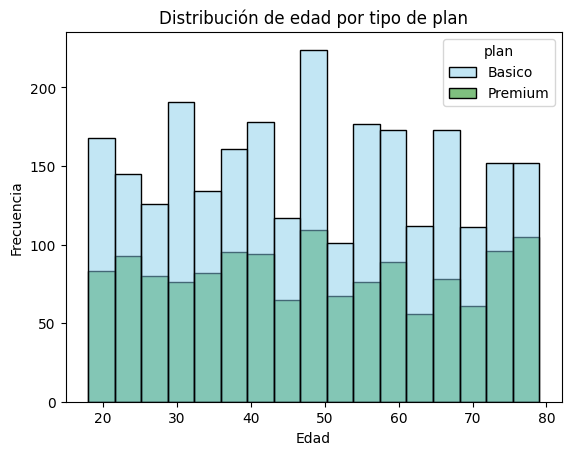

In [126]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución de edades es relativamente uniforme entre los usuarios de ambos planes. No se observan diferencias significativas en los rangos de edad entre clientes Básico y Premium. Aunque las frecuencias del plan Básico son mayores, esto parece estar relacionado con la mayor cantidad de usuarios registrados en dicho plan y no necesariamente con una diferencia en el comportamiento de edad entre ambos grupos.

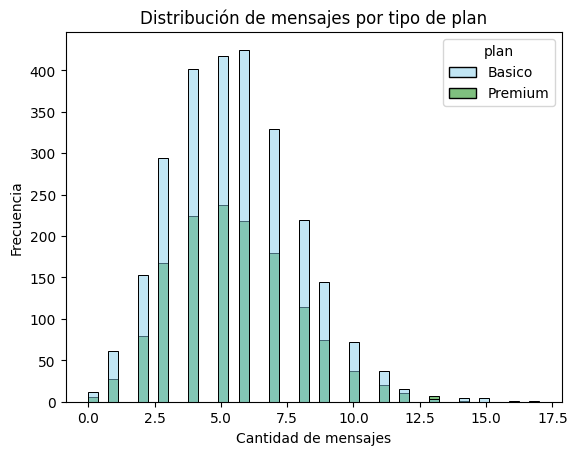

In [127]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green']
)
plt.title('Distribución de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La cantidad de mensajes presenta una distribución sesgada a la derecha, ya que la mayoría de usuarios envía entre 3 y 8 mensajes, mientras que un grupo reducido alcanza valores más altos de hasta 17 mensajes. No se observan diferencias significativas en la forma de la distribución entre los planes Básico y Premium, ya que ambos muestran patrones de comportamiento similares. Aunque las frecuencias del plan Básico son mayores, esto parece estar relacionado con la mayor cantidad de usuarios en dicho plan.

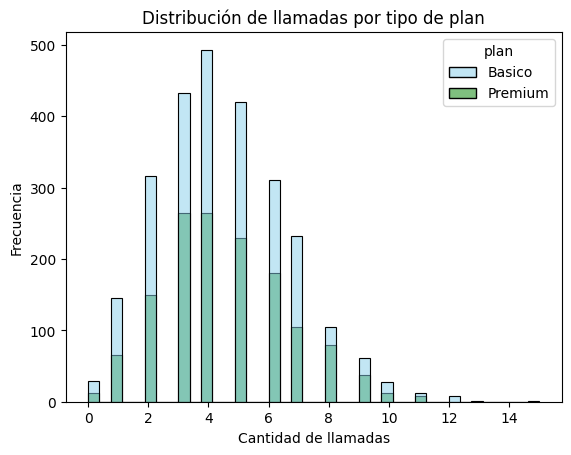

In [128]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green']
)
plt.title('Distribución de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La cantidad de llamadas presenta una distribución sesgada a la derecha. La mayoría de los usuarios realiza entre 2 y 7 llamadas, mientras que un grupo reducido alcanza valores más altos de hasta 15 llamadas. No se observan diferencias significativas entre los planes Básico y Premium, ya que ambos presentan patrones de distribución similares. Las mayores frecuencias observadas en el plan Básico parecen estar asociadas a la mayor cantidad de usuarios registrados en dicho plan.

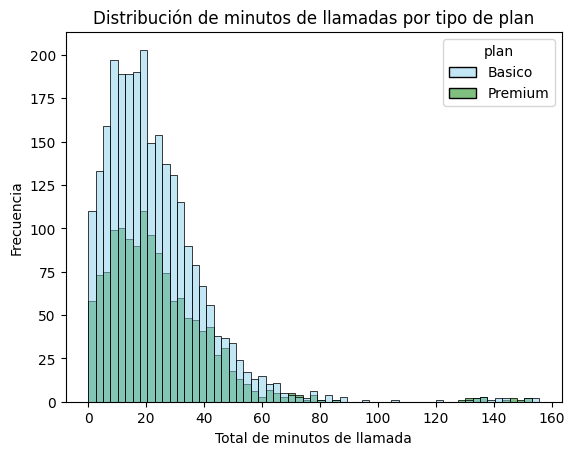

In [129]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green']
)
plt.title('Distribución de minutos de llamadas por tipo de plan')
plt.xlabel('Total de minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución de minutos de llamada presenta un fuerte sesgo a la derecha. La mayoría de los usuarios acumula entre 5 y 40 minutos de conversación, mientras que un grupo reducido alcanza valores considerablemente más altos, llegando hasta aproximadamente 150 minutos. Esto explica por qué la media es superior a la mediana. No se observan diferencias sustanciales entre los planes Básico y Premium en la forma general de la distribución, aunque algunos de los valores más altos corresponden a usuarios del plan Premium

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

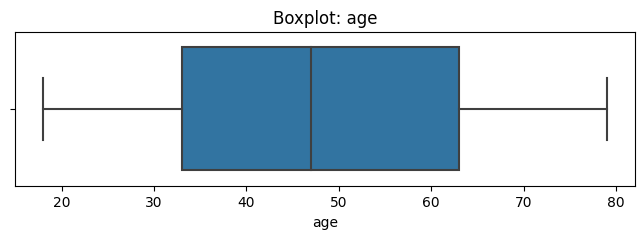

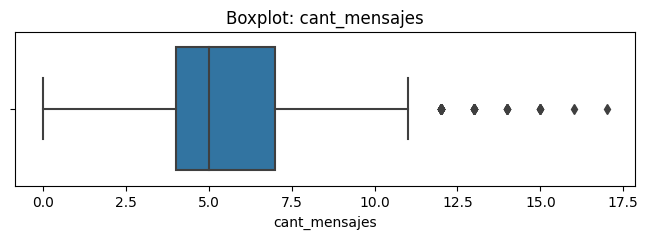

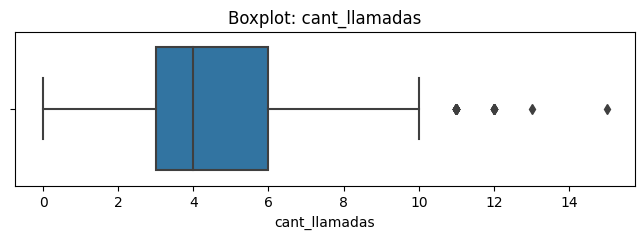

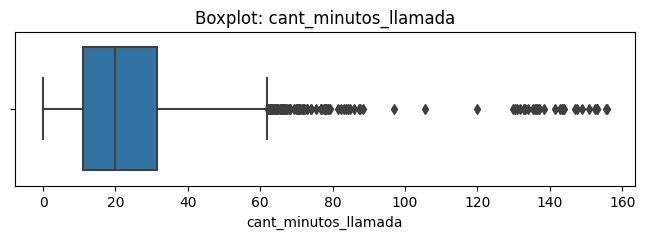

In [130]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas: 
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No se observan valores atípicos. La distribución de edades se encuentra dentro de rangos esperados para la población analizada
- cant_mensajes: Se identifican algunos valores atípicos en el extremo superior, correspondientes a usuarios que envían una cantidad de mensajes superior al comportamiento típico.
- cant_llamadas: Se observan algunos valores atípicos hacia la derecha de la distribución, asociados a usuarios con una frecuencia de llamadas mayor que la mayoría.
- cant_minutos_llamada: Presenta una cantidad considerable de valores atípicos en el extremo superior, reflejando usuarios con tiempos de llamada significativamente más altos que el promedio

In [131]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

In [132]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
Aunque se identificaron algunos valores atípicos en el extremo superior de la distribución, el valor máximo observado (17 mensajes) sigue siendo razonable dentro del contexto del negocio. Estos registros representan usuarios más activos y no evidencian errores de captura, por lo que se conservarán para el análisis.
- cant_llamadas: mantener o no outliers, porqué?
Los valores atípicos observados corresponden a usuarios con una mayor frecuencia de llamadas. El valor máximo registrado (15 llamadas) es plausible y consistente con el comportamiento esperado de algunos clientes más activos, por lo que no se considera necesario eliminar estos registros.
- cant_minutos_llamada: mantener o no outliers, porqué?
Esta variable presenta una mayor cantidad de valores atípicos en el extremo superior, alcanzando hasta 155.69 minutos. Sin embargo, estos valores representan usuarios con un uso intensivo del servicio y no parecen corresponder a errores o inconsistencias en los datos. Por esta razón, se mantendrán para preservar la variabilidad real del comportamiento de los usuarios.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [133]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if (row['cant_llamadas'] < 5
        and row['cant_mensajes'] < 5):
        return 'Bajo uso'
    elif (row['cant_llamadas'] < 10
        and row['cant_mensajes'] < 10):
        return 'Uso medio'
    else:
        return 'Alto uso'
user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [134]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,2022.0,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,2022.0,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,2022.0,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,2022.0,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,2022.0,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [135]:
# Crear columna grupo_edad
def clasificar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'
user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [136]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,2022.0,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,2022.0,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,2022.0,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,2022.0,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,2022.0,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

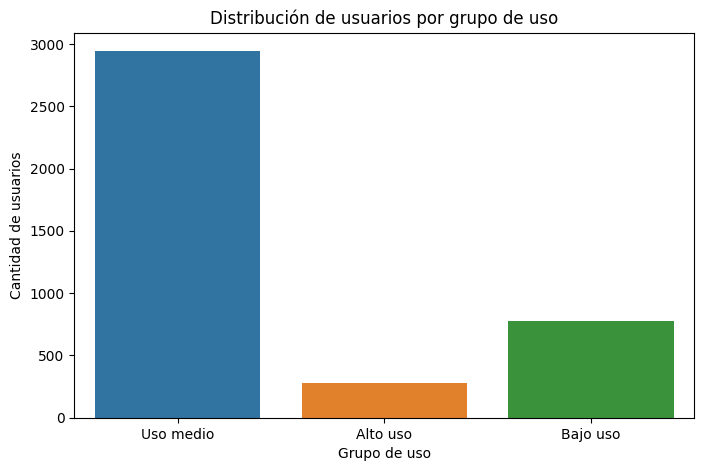

In [137]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8,5))
sns.countplot(
    data=user_profile,
    x='grupo_uso')
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

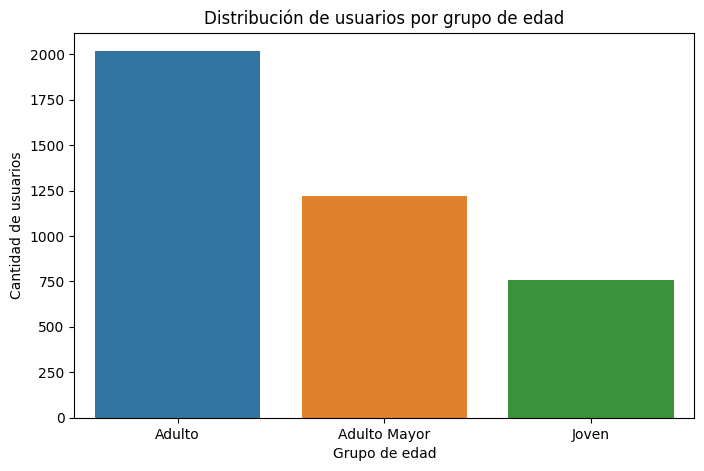

In [138]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8,5))
sns.countplot(
    data=user_profile,
    x='grupo_edad')
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
* La columna city presentaba 469 valores faltantes, equivalentes al 11.7% de los registros.
* La columna churn_date contenía 3534 valores nulos (88.35%), por lo que no fue considerada para el análisis principal.
* Se identificaron 40 registros con fechas futuras (2026) en la columna reg_date, los cuales fueron marcados como valores nulos al ser inconsistentes con el período analizado.
* Las columnas duration y length presentaban altos porcentajes de nulos (55.19% y 44.74% respectivamente). Sin embargo, se comprobó que dependían de la variable type, por lo que corresponden a datos faltantes por diseño y no a errores de captura.

🔍 **Segmentos por Edad**
* Se identificaron tres segmentos: Joven (<30 años), Adulto (30-59 años) y Adulto Mayor (60+ años).
* El segmento Adulto representa la mayor proporción de clientes de ConnectaTel.
* El segmento Adulto Mayor constituye el segundo grupo más numeroso.
* Los usuarios Jóvenes representan la menor proporción de la base de clientes.
  
📊 **Segmentos por Nivel de Uso**

* Se clasificaron los usuarios en Bajo Uso, Uso Medio y Alto Uso según su actividad de llamadas y mensajes.
* La mayoría de los clientes pertenece al segmento Uso Medio, indicando un patrón de consumo moderado.
* El segmento Bajo Uso representa una proporción relevante de usuarios con baja interacción con los servicios.
* El segmento Alto Uso es el más pequeño, pero concentra a los usuarios más activos de la plataforma.
  
➡️ Esto sugiere que ...

* La base de clientes de ConnectaTel está compuesta principalmente por usuarios adultos con patrones de consumo moderados.
* Existe una oportunidad de negocio en los usuarios de Alto Uso, ya que consumen significativamente más llamadas y mensajes que el promedio.
* Los usuarios de Bajo Uso podrían beneficiarse de planes más económicos o simplificados para mejorar su retención.
* La distribución observada indica que la oferta actual parece ajustarse razonablemente al comportamiento de la mayoría de los clientes, aunque existen nichos con necesidades específicas.
  
💡 **Recomendaciones**

* Diseñar o promocionar planes premium orientados a los usuarios de Alto Uso, incorporando mayores beneficios en llamadas y mensajería.
* Evaluar la creación de planes básicos de menor costo para clientes de Bajo Uso, mejorando la percepción de valor y reduciendo el riesgo de abandono.
* Realizar campañas segmentadas dirigidas al grupo Adulto, ya que representa la mayor parte de la base de clientes.
* Monitorear de forma periódica los usuarios con consumos extremadamente altos para identificar oportunidades de upselling y optimización de la oferta comercial.
* Fortalecer los procesos de calidad de datos para evitar registros con fechas futuras y mejorar la completitud de variables relevantes.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`